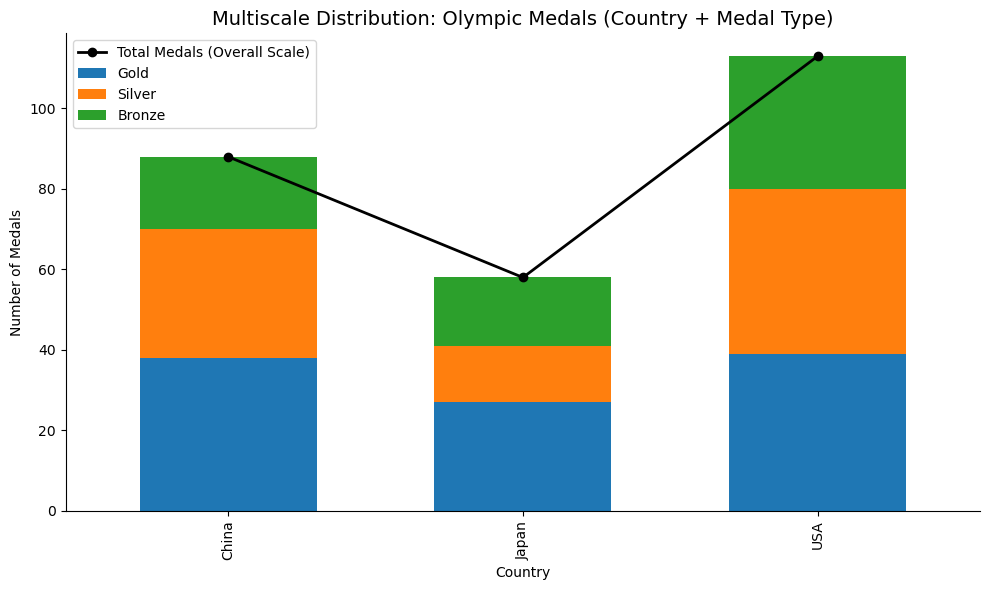

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Realistic Olympic-style dataset
data = pd.DataFrame({
    "Country": ["USA", "USA", "USA",
                "China", "China", "China",
                "Japan", "Japan", "Japan"],
    
    "Medal": ["Gold", "Silver", "Bronze",
              "Gold", "Silver", "Bronze",
              "Gold", "Silver", "Bronze"],
    
    "Count": [39, 41, 33,
              38, 32, 18,
              27, 14, 17]
})

# Pivot table (Country × Medal type)
pivot = data.pivot(index="Country", columns="Medal", values="Count").fillna(0)

# Ensure consistent order
pivot = pivot[["Gold", "Silver", "Bronze"]]

# --- PLOT MULTISCALE DISTRIBUTION ---
fig, ax = plt.subplots(figsize=(10, 6))

# Bottom scale: stacked bars (medal distribution)
pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.6
)

# Top scale: total medals per country
totals = pivot.sum(axis=1)
ax.plot(
    range(len(totals)),
    totals,
    color="black",
    marker="o",
    linewidth=2,
    label="Total Medals (Overall Scale)"
)

# Labels & styling
ax.set_title("Multiscale Distribution: Olympic Medals (Country + Medal Type)", fontsize=14)
ax.set_xlabel("Country")
ax.set_ylabel("Number of Medals")

ax.legend()

# Clean look
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()